In [3]:
!pip install tensorflow tensorflow-hub opencv-python matplotlib pillow

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
model = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
image_paths = ['/kaggle/input/datasets/norahaldossary/images/cats.jpg', 
               '/kaggle/input/datasets/norahaldossary/images/people by big ben.jpeg',
               '/kaggle/input/datasets/norahaldossary/images/persons and bicycle.png',
               '/kaggle/input/datasets/norahaldossary/images/persons with cell phones.png',
               '/kaggle/input/datasets/norahaldossary/images/pizza.png']

def load_image(path):
    img = Image.open(path).convert("RGB") 
    img = np.array(img)
    return img

images = [load_image(p) for p in image_paths]

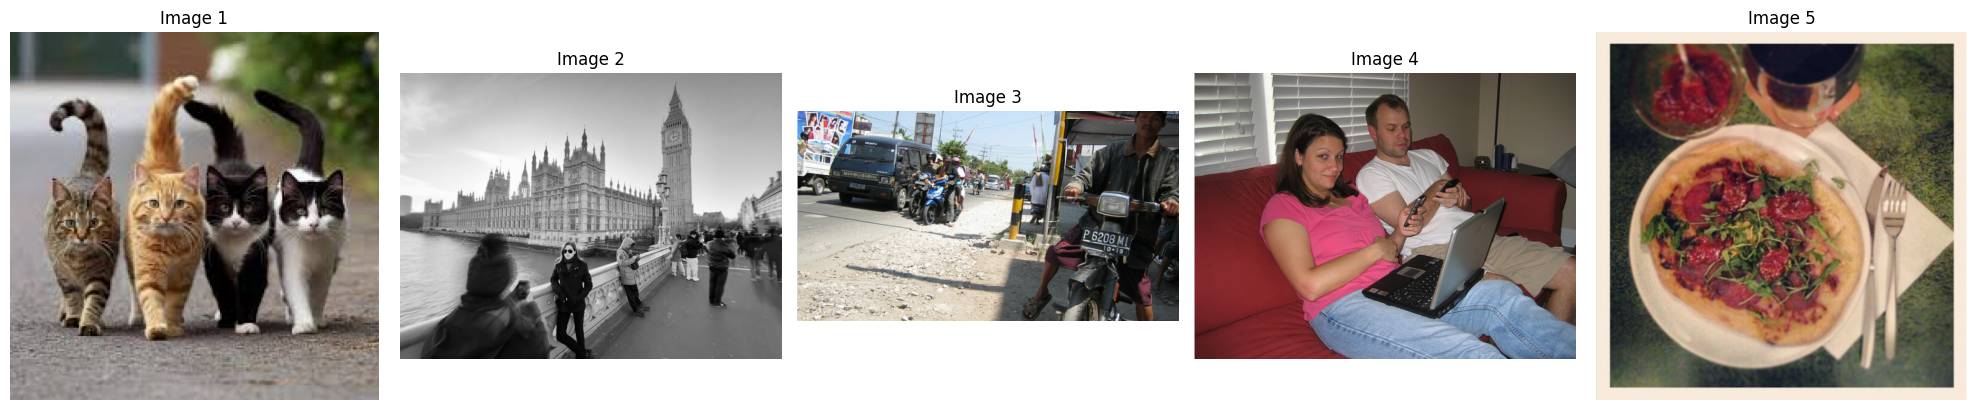

In [37]:
def display_images_row(images):
    n = len(images)

    plt.figure(figsize=(4*n, 4))  # width scales with number of images

    for i, img in enumerate(images):
        plt.subplot(1, n, i+1)  # 1 row, n columns
        plt.imshow(img)
        plt.title(f"Image {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
display_images_row(images)

In [6]:
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow',
    22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack',
    28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee',
    35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat',
    40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket',
    44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 50: 'spoon',
    51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange',
    56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 60: 'donut',
    61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed',
    67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse',
    75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave', 79: 'oven',
    80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book', 85: 'clock',
    86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'
}

In [7]:
def run_inference(image):
    # Ensure image has 3 channels
    if image.shape[-1] == 4:
        image = image[:, :, :3]

    input_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]

    outputs = model(input_tensor)

    result = {key: value.numpy() for key, value in outputs.items()}
    return result

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def visualize_predictions_and_mask(image, outputs, threshold=0.5):
    h, w, _ = image.shape

    boxes = outputs['detection_boxes'][0]
    classes = outputs['detection_classes'][0].astype(int)
    scores = outputs['detection_scores'][0]
    masks = outputs['detection_masks'][0]

    # Copy image for predictions
    pred_img = image.copy()

    # Create empty mask canvas
    final_mask = np.zeros((h, w))

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        y1, x1, y2, x2 = boxes[i]
        y1, x1, y2, x2 = int(y1*h), int(x1*w), int(y2*h), int(x2*w)

        if x2 <= x1 or y2 <= y1:
            continue

        label = COCO_LABELS.get(classes[i], f"Class {classes[i]}")
        score = scores[i]

        # -------------------------------
        # ✅ Draw bounding box + label
        # -------------------------------
        cv2.rectangle(pred_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        text = f"{label}: {score:.2f}"
        cv2.putText(pred_img, text, (x1, max(y1 - 10, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 2)

        # -------------------------------
        # ✅ Create segmentation mask
        # -------------------------------
        mask = masks[i]
        mask = cv2.resize(mask, (x2 - x1, y2 - y1))
        mask = mask > 0.5

        final_mask[y1:y2, x1:x2][mask] = i + 1  # unique object ID

    # -------------------------------
    # ✅ Plot side-by-side
    # -------------------------------
    plt.figure(figsize=(12, 5))

    # Left: Predictions
    plt.subplot(1, 2, 1)
    plt.imshow(pred_img)
    plt.title("Predictions (Boxes + Labels)")
    plt.axis("off")

    # Right: Mask
    plt.subplot(1, 2, 2)
    plt.imshow(final_mask, cmap='viridis')
    plt.title("Segmentation Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

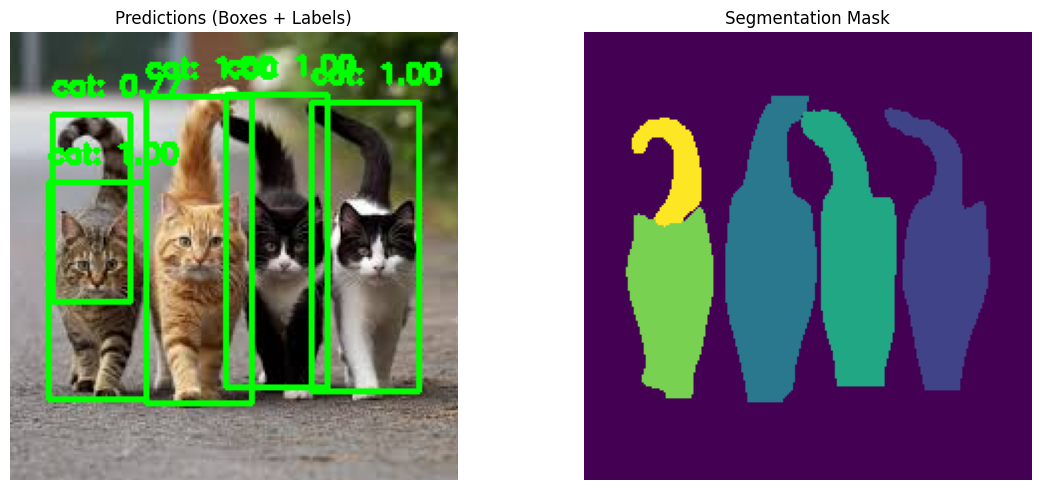

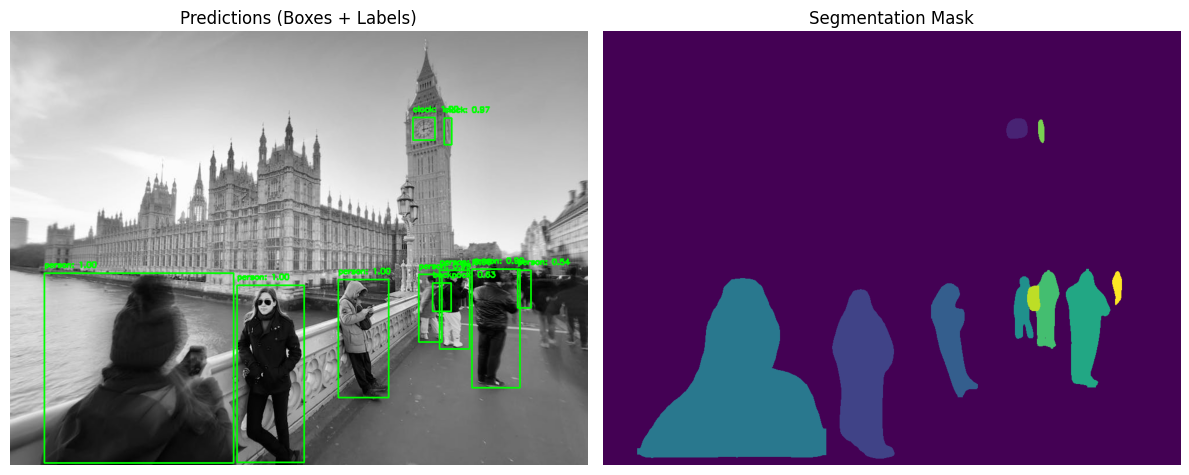

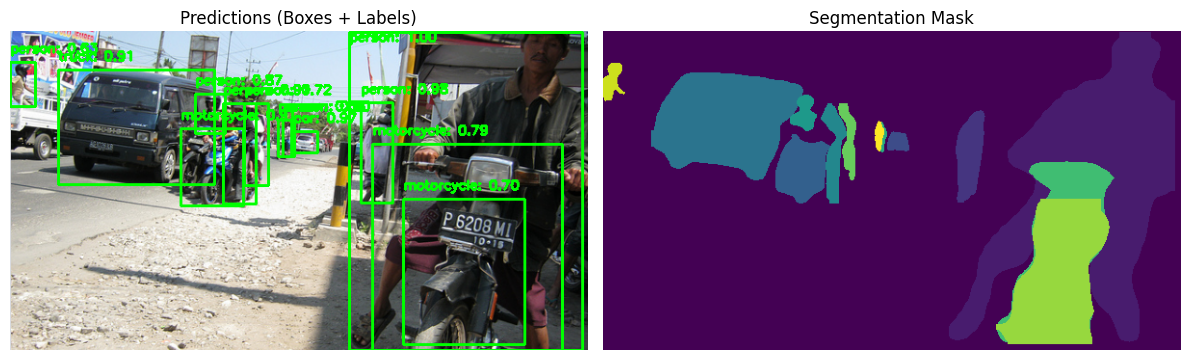

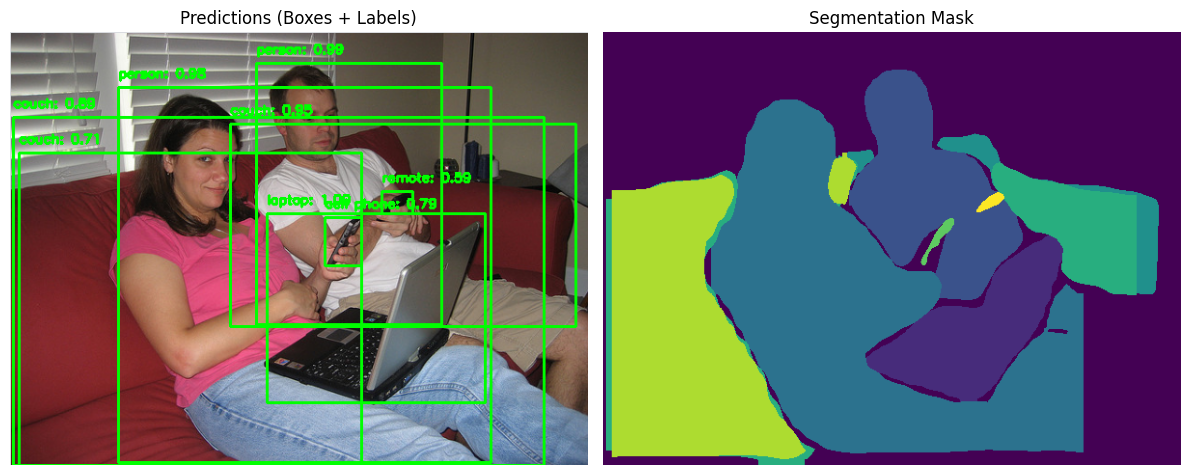

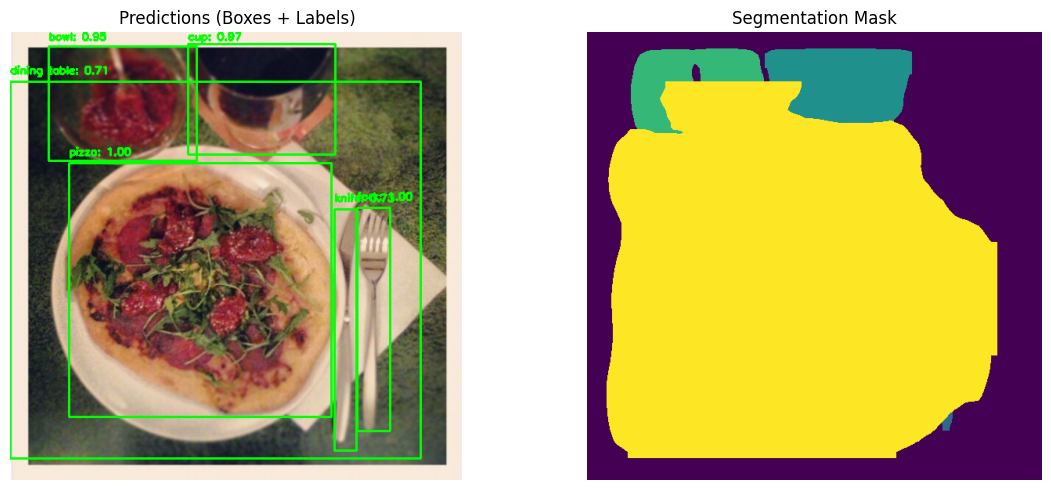

In [33]:
for i, img in enumerate(images):
    outputs = run_inference(img)
    visualize_predictions_and_mask(img, outputs, threshold=0.5)